# HDF5 → FITS Conversion & Comparison with Existing Pipeline Data

**Kernel**: `sam3`  
**Goal**: Convert overlapping HDF5 galaxies to FITS via `mockimgs_sb_compute_images`,  
compare with existing `FIREbox-DR1/SB_maps` FITS, and run our 8-bit preprocessing to see visual differences.

---

In [1]:
import sys, os, subprocess, re, glob
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import cv2

PROJECT_ROOT = '/home/yuqyan/Yuqi/LSB-AI-Detection'
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

HDF5_DIR = os.path.join(
    PROJECT_ROOT, 'data/01_raw/LSB_and_Satellites/FIREbox_ARRAKIHS_sample'
)
FITS_DIR = os.path.join(
    PROJECT_ROOT, 'data/01_raw/LSB_and_Satellites/FIREbox-DR1/SB_maps'
)
OUT_DIR = '/tmp/hdf5_to_fits_comparison'
os.makedirs(OUT_DIR, exist_ok=True)

## 1  Identify Overlapping Galaxies

These galaxies exist in **both** the HDF5 sample and the existing FITS pipeline.  
We'll convert the HDF5 → FITS and compare with the existing FITS to check for differences.

In [2]:
# Extract galaxy IDs from FITS files
fits_files = sorted(os.listdir(FITS_DIR))
fits_ids = set()
for fn in fits_files:
    m = re.search(r'Fbox-(\d+)', fn)
    if m:
        fits_ids.add(int(m.group(1)))

# Extract galaxy IDs from HDF5 files
hdf5_files = sorted([f for f in os.listdir(HDF5_DIR) if f.endswith('.hdf5')])
hdf5_ids = set()
hdf5_id_to_file = {}
for fn in hdf5_files:
    m = re.search(r'_(\d{5})_', fn)
    if m:
        gid = int(m.group(1))
        hdf5_ids.add(gid)
        hdf5_id_to_file[gid] = fn

overlap = sorted(fits_ids & hdf5_ids)
print(f'Overlapping galaxy IDs ({len(overlap)}): {overlap}')

Overlapping galaxy IDs (36): [11, 13, 19, 22, 24, 25, 27, 28, 29, 30, 32, 33, 34, 35, 36, 37, 38, 39, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 53, 56, 62, 63, 64, 66, 68, 72]


In [8]:
from astropy.io import fits
hdr = fits.getheader('/home/yuqyan/Yuqi/LSB-AI-Detection/data/01_raw/LSB_and_Satellites/FIREbox-DR1/SB_maps/magnitudes-Fbox-11-fo-VIS2.fits.gz')
print('\n'.join(str(c) for c in hdr['COMMENT']))


command line:
/opt/anaconda3/envs/arrakihs_kernel/bin/mockimgs_sb_compute_images /User
s/lt589/Documents/Data_transfer/FIREbox/nbody_Fbox_halo_11.hdf5 --instru
ment=/Users/lt589/Documents/Scripts/ARK_VIS2.py --distance=35 --los 0 0
1 --rsp_mode=None --rsp_fac=0.6 -o /Users/lt589/Documents/Data_transfer/
magnitudes-Fbox-11-fo-VIS2.fits


## 2  Convert HDF5 → FITS via `mockimgs_sb_compute_images`

Command:
```bash
mockimgs_sb_compute_images snapshot.hdf5 \
    --instrument arrakihs_vis_G \
    --distance 35 \
    --rsp_mode const --rsp_val 1.5 \
    -o output.fits
```

⚠️ This will fail if `pNbody` config is missing. The cell below catches the error gracefully.

In [8]:
# Pick a few overlapping galaxies to convert (first 5 for speed)
test_ids = overlap[:5]
converted = {}  # gid -> output fits path
failed = {}     # gid -> stderr

for gid in test_ids:
    hdf5_path = os.path.join(HDF5_DIR, hdf5_id_to_file[gid])
    out_fits  = os.path.join(OUT_DIR, f'converted-Fbox-{gid:02d}.fits')

    cmd = [
        'mockimgs_sb_compute_images', hdf5_path,
        '--instrument', 'arrakihs_vis_G',
        '--distance', '35',
        '--rsp_mode', 'const',
        '--rsp_val', '1.5',
        '-o', out_fits,
    ]
    print(f'\n--- Galaxy {gid} ---')
    print('CMD:', ' '.join(cmd))

    result = subprocess.run(cmd, capture_output=True, text=True, timeout=120)
    if result.returncode == 0 and os.path.exists(out_fits):
        converted[gid] = out_fits
        print(f'  ✅ OK → {out_fits}')
        # Also check for .gz
        if os.path.exists(out_fits + '.gz'):
            converted[gid] = out_fits + '.gz'
    else:
        # Check if .gz was created
        if os.path.exists(out_fits + '.gz'):
            converted[gid] = out_fits + '.gz'
            print(f'  ✅ OK (gz) → {out_fits}.gz')
        else:
            err = result.stderr[-500:] if result.stderr else 'no stderr'
            failed[gid] = err
            print(f'  ❌ FAILED: {err[:200]}')

print(f'\n\nConverted: {len(converted)} / {len(test_ids)}')
if failed:
    print(f'Failed:    {len(failed)} — likely pNbody config issue')


--- Galaxy 11 ---
CMD: mockimgs_sb_compute_images /home/yuqyan/Yuqi/LSB-AI-Detection/data/01_raw/LSB_and_Satellites/FIREbox_ARRAKIHS_sample/pnbody_FB15N1024_old_1200_00011_max_Rvir_325kpc.hdf5 --instrument arrakihs_vis_G --distance 35 --rsp_mode const --rsp_val 1.5 -o /tmp/hdf5_to_fits_comparison/converted-Fbox-11.fits
  ✅ OK (gz) → /tmp/hdf5_to_fits_comparison/converted-Fbox-11.fits.gz

--- Galaxy 13 ---
CMD: mockimgs_sb_compute_images /home/yuqyan/Yuqi/LSB-AI-Detection/data/01_raw/LSB_and_Satellites/FIREbox_ARRAKIHS_sample/pnbody_FB15N1024_old_1200_00013_max_Rvir_325kpc.hdf5 --instrument arrakihs_vis_G --distance 35 --rsp_mode const --rsp_val 1.5 -o /tmp/hdf5_to_fits_comparison/converted-Fbox-13.fits
  ✅ OK (gz) → /tmp/hdf5_to_fits_comparison/converted-Fbox-13.fits.gz

--- Galaxy 19 ---
CMD: mockimgs_sb_compute_images /home/yuqyan/Yuqi/LSB-AI-Detection/data/01_raw/LSB_and_Satellites/FIREbox_ARRAKIHS_sample/pnbody_FB15N1024_old_1200_00019_max_Rvir_325kpc.hdf5 --instrument arrakihs_vi

## 3  Compare Converted FITS vs Existing FITS

For each successfully converted galaxy, compare:
- Raw FITS pixel distributions
- Header metadata differences  
- Visual appearance in magnitude and flux scales

In [9]:
def load_fits_data(fpath):
    """Load FITS image data and header."""
    with fits.open(fpath) as hdul:
        return hdul[0].data.copy(), hdul[0].header.copy()

def find_existing_fits(gid, orientation='eo'):
    """Find the existing FITS file for a galaxy ID."""
    pattern = os.path.join(FITS_DIR, f'magnitudes-Fbox-{gid}-{orientation}-VIS2.fits.gz')
    matches = glob.glob(pattern)
    return matches[0] if matches else None


=== Galaxy 11 ===
Converted shape: (4096, 4096), Existing shape: (1072, 1072)

Header differences:
  FILTER              : converted=BastI_GAIA_G  existing=BPASS230_ARK_VIS2
  FOVX                : converted=1.5641680537665499  existing=0.9826408563674109
  FOVY                : converted=1.5641680537665499  existing=0.9826408563674109
  GITTAG              : converted=65dc7e49d6773a70dd7430ce7d4c1e30c662dcf9  existing=5aff21571429e246c1fcb458ddacc3265654e776
  HOSTNAME            : converted=u24-chiivm0-605  existing=J6KMWHN6J0.local
  NAME                : converted=arrakihs_vis_G  existing=arrakihs_vis
  NAXIS1              : converted=4096  existing=1072
  NAXIS2              : converted=4096  existing=1072
  NX                  : converted=4096  existing=1072
  NY                  : converted=4096  existing=1072
  OBJ_LOS             : converted=[0.000,0.000,1.000]  existing=[1.000,0.000,0.000]
  OBJ_NAME            : converted=pnbody_FB15N1024_old_1200_00011_max_Rvir_325kpc.hdf5

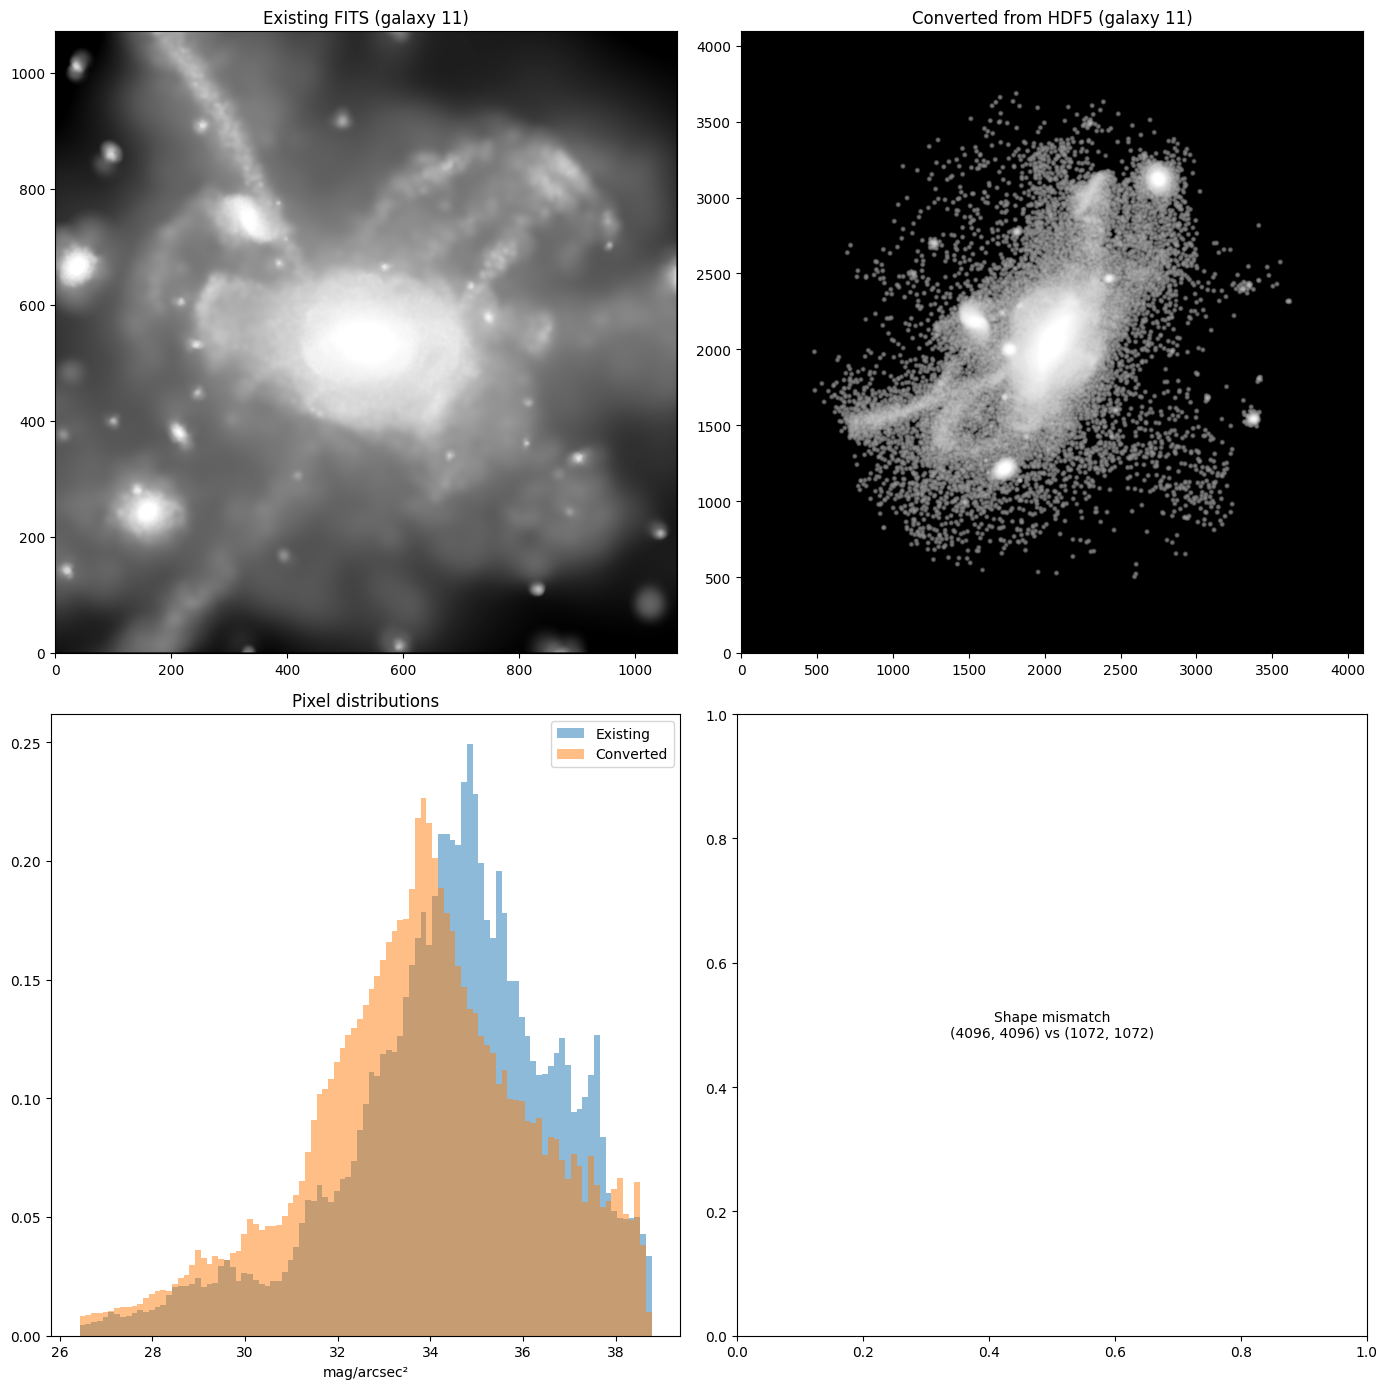


=== Galaxy 13 ===
Converted shape: (4096, 4096), Existing shape: (1072, 1072)

Header differences:
  FILTER              : converted=BastI_GAIA_G  existing=BPASS230_ARK_VIS2
  FOVX                : converted=1.5641680537665499  existing=0.9826408563674109
  FOVY                : converted=1.5641680537665499  existing=0.9826408563674109
  GITTAG              : converted=65dc7e49d6773a70dd7430ce7d4c1e30c662dcf9  existing=5aff21571429e246c1fcb458ddacc3265654e776
  HOSTNAME            : converted=u24-chiivm0-605  existing=J6KMWHN6J0.local
  NAME                : converted=arrakihs_vis_G  existing=arrakihs_vis
  NAXIS1              : converted=4096  existing=1072
  NAXIS2              : converted=4096  existing=1072
  NX                  : converted=4096  existing=1072
  NY                  : converted=4096  existing=1072
  OBJ_LOS             : converted=[0.000,0.000,1.000]  existing=[1.000,0.000,0.000]
  OBJ_NAME            : converted=pnbody_FB15N1024_old_1200_00013_max_Rvir_325kpc.hdf5

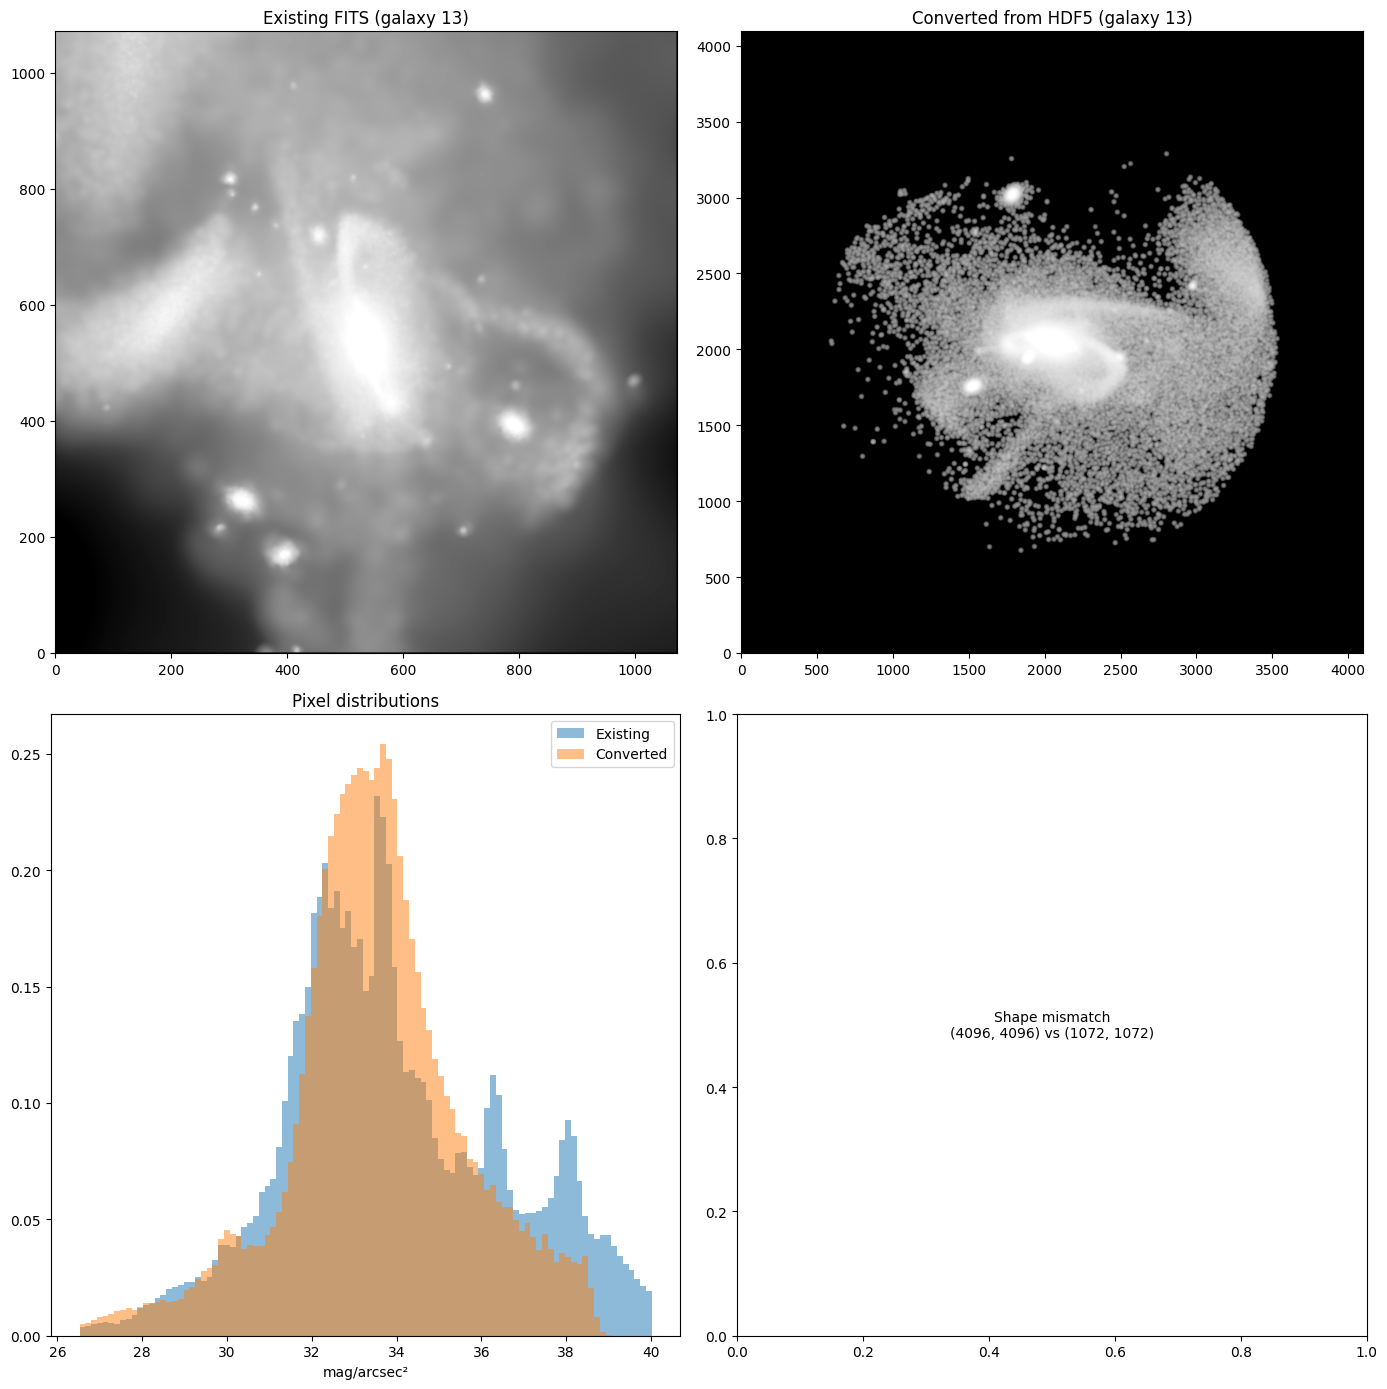


=== Galaxy 19 ===
Converted shape: (4096, 4096), Existing shape: (1072, 1072)

Header differences:
  FILTER              : converted=BastI_GAIA_G  existing=BPASS230_ARK_VIS2
  FOVX                : converted=1.5641680537665499  existing=0.9826408563674109
  FOVY                : converted=1.5641680537665499  existing=0.9826408563674109
  GITTAG              : converted=65dc7e49d6773a70dd7430ce7d4c1e30c662dcf9  existing=5aff21571429e246c1fcb458ddacc3265654e776
  HOSTNAME            : converted=u24-chiivm0-605  existing=J6KMWHN6J0.local
  NAME                : converted=arrakihs_vis_G  existing=arrakihs_vis
  NAXIS1              : converted=4096  existing=1072
  NAXIS2              : converted=4096  existing=1072
  NX                  : converted=4096  existing=1072
  NY                  : converted=4096  existing=1072
  OBJ_LOS             : converted=[0.000,0.000,1.000]  existing=[1.000,0.000,0.000]
  OBJ_NAME            : converted=pnbody_FB15N1024_old_1200_00019_max_Rvir_325kpc.hdf5

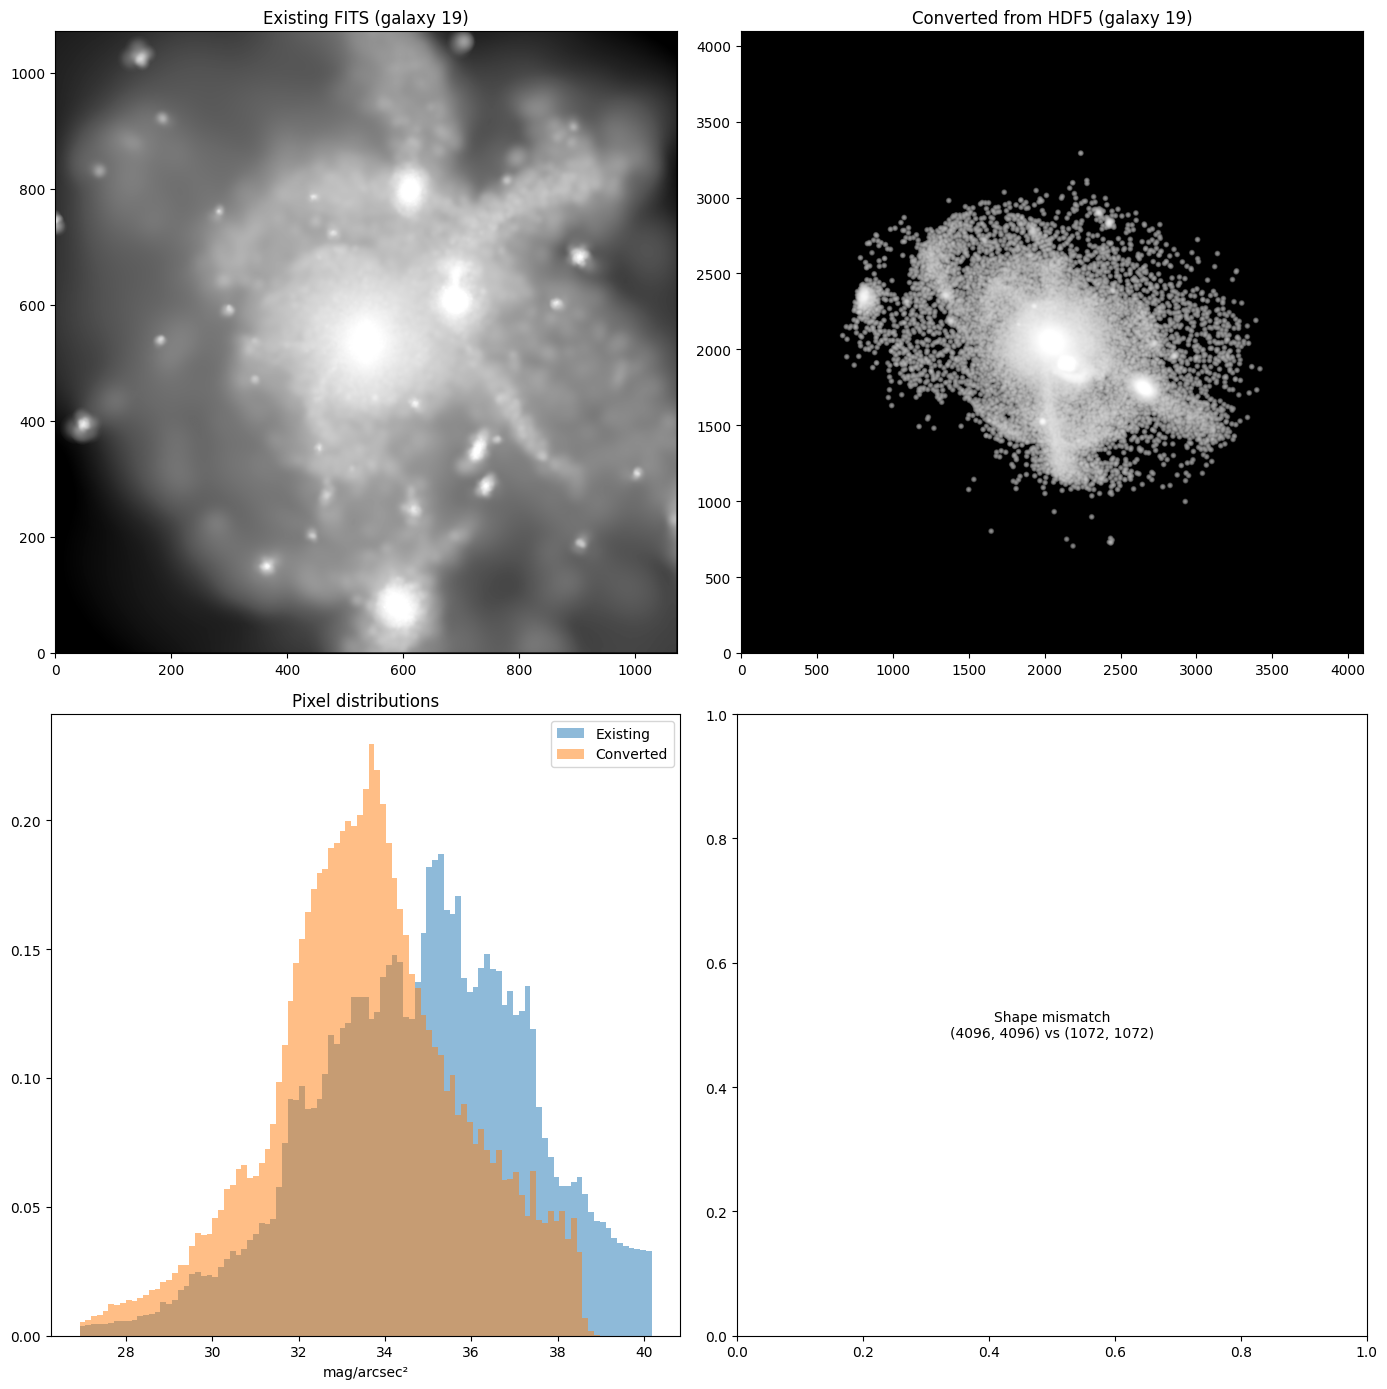


=== Galaxy 22 ===
Converted shape: (4096, 4096), Existing shape: (1072, 1072)

Header differences:
  FILTER              : converted=BastI_GAIA_G  existing=BPASS230_ARK_VIS2
  FOVX                : converted=1.5641680537665499  existing=0.9826408563674109
  FOVY                : converted=1.5641680537665499  existing=0.9826408563674109
  GITTAG              : converted=65dc7e49d6773a70dd7430ce7d4c1e30c662dcf9  existing=5aff21571429e246c1fcb458ddacc3265654e776
  HOSTNAME            : converted=u24-chiivm0-605  existing=J6KMWHN6J0.local
  NAME                : converted=arrakihs_vis_G  existing=arrakihs_vis
  NAXIS1              : converted=4096  existing=1072
  NAXIS2              : converted=4096  existing=1072
  NX                  : converted=4096  existing=1072
  NY                  : converted=4096  existing=1072
  OBJ_LOS             : converted=[0.000,0.000,1.000]  existing=[1.000,0.000,0.000]
  OBJ_NAME            : converted=pnbody_FB15N1024_old_1200_00022_max_Rvir_325kpc.hdf5

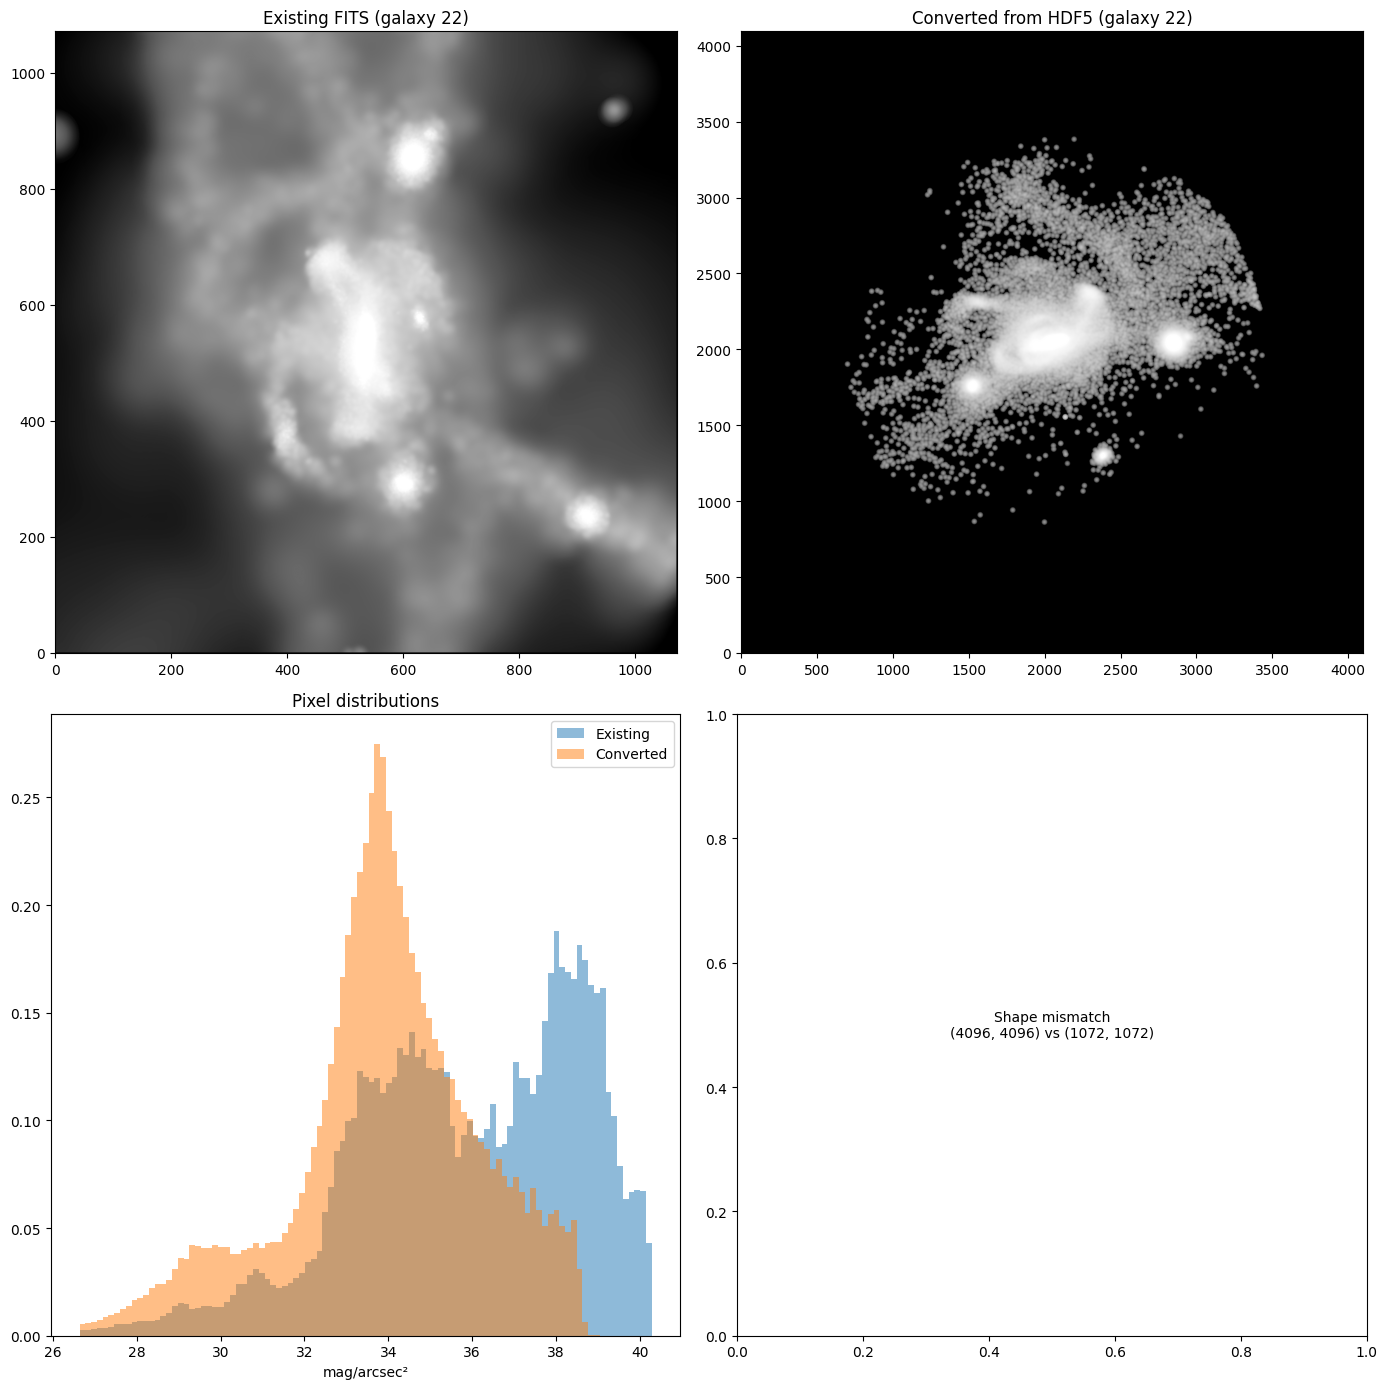


=== Galaxy 24 ===
Converted shape: (4096, 4096), Existing shape: (1072, 1072)

Header differences:
  FILTER              : converted=BastI_GAIA_G  existing=BPASS230_ARK_VIS2
  FOVX                : converted=1.5641680537665499  existing=0.9826408563674109
  FOVY                : converted=1.5641680537665499  existing=0.9826408563674109
  GITTAG              : converted=65dc7e49d6773a70dd7430ce7d4c1e30c662dcf9  existing=5aff21571429e246c1fcb458ddacc3265654e776
  HOSTNAME            : converted=u24-chiivm0-605  existing=J6KMWHN6J0.local
  NAME                : converted=arrakihs_vis_G  existing=arrakihs_vis
  NAXIS1              : converted=4096  existing=1072
  NAXIS2              : converted=4096  existing=1072
  NX                  : converted=4096  existing=1072
  NY                  : converted=4096  existing=1072
  OBJ_LOS             : converted=[0.000,0.000,1.000]  existing=[1.000,0.000,0.000]
  OBJ_NAME            : converted=pnbody_FB15N1024_old_1200_00024_max_Rvir_325kpc.hdf5

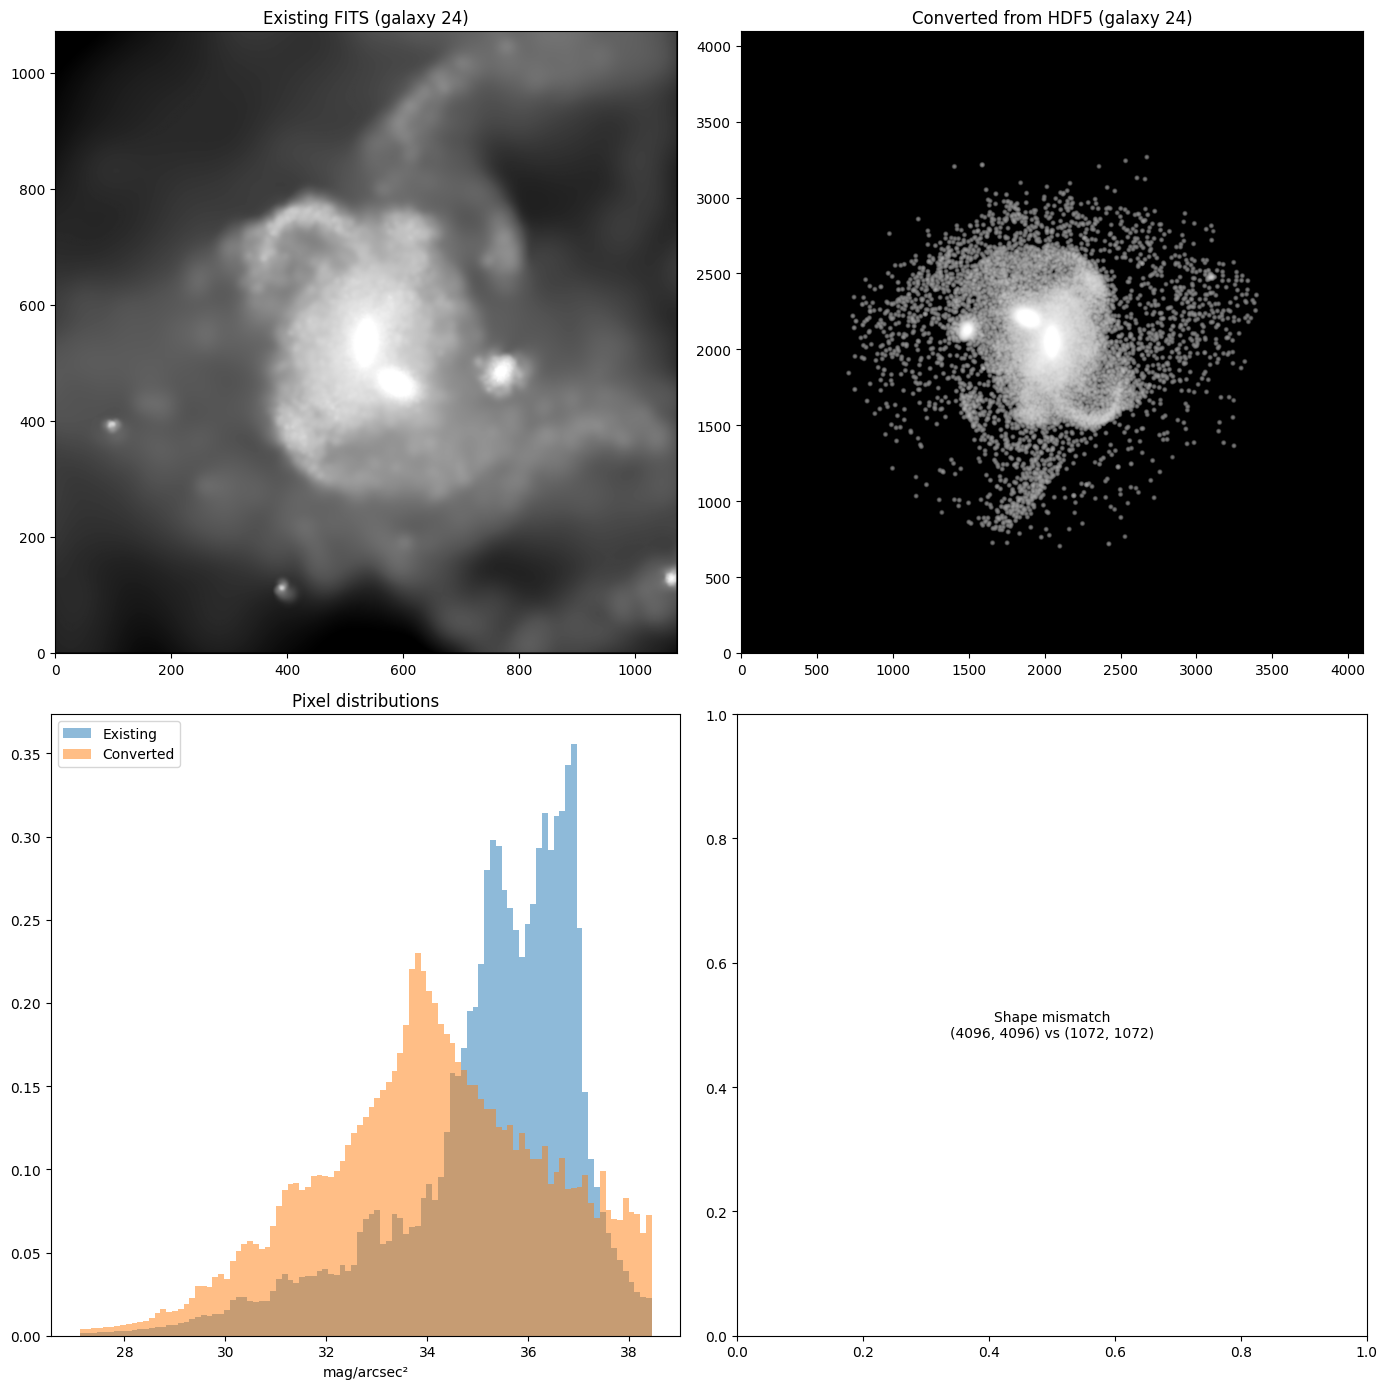

In [10]:
if not converted:
    print('⚠️  No galaxies were converted successfully.')
    print('    This is expected — pNbody config directory is missing.')
    print('    Fix: reinstall pNbody with proper config files.')
    print()
    print('    Skipping to Section 4 (8-bit comparison using existing data only).')
else:
    for gid, conv_path in converted.items():
        exist_path = find_existing_fits(gid)
        if exist_path is None:
            print(f'Galaxy {gid}: no existing FITS found, skipping')
            continue

        conv_data, conv_hdr = load_fits_data(conv_path)
        exist_data, exist_hdr = load_fits_data(exist_path)

        print(f'\n=== Galaxy {gid} ===')
        print(f'Converted shape: {conv_data.shape}, Existing shape: {exist_data.shape}')

        # Header comparison
        print('\nHeader differences:')
        all_keys = set(list(conv_hdr.keys()) + list(exist_hdr.keys()))
        for k in sorted(all_keys):
            if k in ('', 'COMMENT', 'HISTORY'):
                continue
            cv = conv_hdr.get(k, 'MISSING')
            ev = exist_hdr.get(k, 'MISSING')
            if cv != ev:
                print(f'  {k:20s}: converted={cv}  existing={ev}')

        # Visual comparison
        fig, axes = plt.subplots(2, 2, figsize=(14, 14))

        # Mag scale
        vmin_m = min(np.nanpercentile(conv_data[conv_data < 90], 1),
                     np.nanpercentile(exist_data[exist_data < 90], 1))
        vmax_m = max(np.nanpercentile(conv_data[conv_data < 90], 99),
                     np.nanpercentile(exist_data[exist_data < 90], 99))

        axes[0, 0].imshow(exist_data, cmap='Greys', origin='lower', vmin=vmin_m, vmax=vmax_m)
        axes[0, 0].set_title(f'Existing FITS (galaxy {gid})')
        axes[0, 1].imshow(conv_data, cmap='Greys', origin='lower', vmin=vmin_m, vmax=vmax_m)
        axes[0, 1].set_title(f'Converted from HDF5 (galaxy {gid})')

        # Pixel histogram
        bins = np.linspace(vmin_m, vmax_m, 100)
        axes[1, 0].hist(exist_data[exist_data < 90].ravel(), bins=bins, alpha=0.5, label='Existing', density=True)
        axes[1, 0].hist(conv_data[conv_data < 90].ravel(), bins=bins, alpha=0.5, label='Converted', density=True)
        axes[1, 0].legend(); axes[1, 0].set_xlabel('mag/arcsec²')
        axes[1, 0].set_title('Pixel distributions')

        # Residual (only if same shape)
        if conv_data.shape == exist_data.shape:
            diff = conv_data.astype(np.float64) - exist_data.astype(np.float64)
            mask = (conv_data < 90) & (exist_data < 90)
            diff[~mask] = np.nan
            im = axes[1, 1].imshow(diff, cmap='RdBu_r', origin='lower',
                                    vmin=-1, vmax=1)
            plt.colorbar(im, ax=axes[1, 1], label='Δ mag')
            axes[1, 1].set_title('Residual (converted − existing)')
        else:
            axes[1, 1].text(0.5, 0.5, f'Shape mismatch\n{conv_data.shape} vs {exist_data.shape}',
                           ha='center', va='center', transform=axes[1, 1].transAxes)

        plt.tight_layout(); plt.show()

## 4  8-bit Pipeline Comparison

Run our `LSBPreprocessor` on both converted and existing FITS to see  
how they look after the full training pipeline rendering.

If no conversion succeeded (pNbody broken), we compare existing  
galaxies across orientations (eo vs fo) as baseline.

In [4]:
from src.data.preprocessing import LSBPreprocessor, LinearMagnitudePreprocessor

asinh_proc = LSBPreprocessor(zeropoint=22.5, nonlinearity=100.0, target_size=(1024, 1024))
linear_proc = LinearMagnitudePreprocessor(global_mag_min=20.0, global_mag_max=35.0, target_size=(1024, 1024))

In [5]:
if converted:
    # Case A: compare converted vs existing through 8-bit pipeline
    for gid, conv_path in list(converted.items())[:3]:
        exist_path = find_existing_fits(gid)
        if exist_path is None:
            continue

        conv_data, _ = load_fits_data(conv_path)
        exist_data, _ = load_fits_data(exist_path)

        # Asinh stretch
        conv_8bit = asinh_proc.process(conv_data)
        exist_8bit = asinh_proc.process(exist_data)

        # Linear stretch
        conv_linear = linear_proc.process(conv_data)
        exist_linear = linear_proc.process(exist_data)

        fig, axes = plt.subplots(2, 2, figsize=(16, 16))
        axes[0, 0].imshow(exist_8bit); axes[0, 0].set_title(f'Existing (Asinh) — Galaxy {gid}')
        axes[0, 1].imshow(conv_8bit); axes[0, 1].set_title(f'Converted (Asinh) — Galaxy {gid}')
        axes[1, 0].imshow(exist_linear); axes[1, 0].set_title(f'Existing (Linear) — Galaxy {gid}')
        axes[1, 1].imshow(conv_linear); axes[1, 1].set_title(f'Converted (Linear) — Galaxy {gid}')
        for ax in axes.ravel():
            ax.axis('off')
        plt.tight_layout(); plt.show()

else:
    # Case B: pNbody broken — compare eo vs fo orientations as baseline
    print('pNbody conversion failed — comparing eo vs fo orientations instead.')
    print('This shows how the SAME galaxy looks from two different viewing angles.')
    print()

    for gid in overlap[:4]:
        eo_path = find_existing_fits(gid, 'eo')
        fo_path = find_existing_fits(gid, 'fo')
        if not eo_path or not fo_path:
            continue

        eo_data, _ = load_fits_data(eo_path)
        fo_data, _ = load_fits_data(fo_path)

        eo_8bit = asinh_proc.process(eo_data)
        fo_8bit = asinh_proc.process(fo_data)
        eo_linear = linear_proc.process(eo_data)
        fo_linear = linear_proc.process(fo_data)

        fig, axes = plt.subplots(2, 2, figsize=(16, 16))
        axes[0, 0].imshow(eo_8bit); axes[0, 0].set_title(f'Edge-on Asinh — Galaxy {gid}')
        axes[0, 1].imshow(fo_8bit); axes[0, 1].set_title(f'Face-on Asinh — Galaxy {gid}')
        axes[1, 0].imshow(eo_linear); axes[1, 0].set_title(f'Edge-on Linear — Galaxy {gid}')
        axes[1, 1].imshow(fo_linear); axes[1, 1].set_title(f'Face-on Linear — Galaxy {gid}')
        for ax in axes.ravel():
            ax.axis('off')
        plt.tight_layout(); plt.show()

NameError: name 'find_existing_fits' is not defined

## 5  Batch Conversion: All Overlapping Galaxies

Once `mockimgs_sb_compute_images` is working, run this cell to convert all 36 overlapping galaxies.  
⚠️ Skip this cell until pNbody is fixed.

In [ ]:
BATCH_RUN = False  # ← Set to True once pNbody is fixed

if BATCH_RUN:
    batch_out = os.path.join(OUT_DIR, 'batch')
    os.makedirs(batch_out, exist_ok=True)

    results = {'ok': [], 'fail': []}
    for gid in overlap:
        hdf5_path = os.path.join(HDF5_DIR, hdf5_id_to_file[gid])
        out_fits = os.path.join(batch_out, f'converted-Fbox-{gid:02d}.fits')
        cmd = [
            'mockimgs_sb_compute_images', hdf5_path,
            '--instrument', 'arrakihs_vis_G',
            '--distance', '35',
            '--rsp_mode', 'const', '--rsp_val', '1.5',
            '-o', out_fits,
        ]
        r = subprocess.run(cmd, capture_output=True, text=True, timeout=180)
        exists = os.path.exists(out_fits) or os.path.exists(out_fits + '.gz')
        if r.returncode == 0 and exists:
            results['ok'].append(gid)
        else:
            results['fail'].append(gid)
        print(f'Galaxy {gid:3d}: {"OK" if gid in results["ok"] else "FAIL"}')

    print(f'\nBatch done: {len(results["ok"])} OK, {len(results["fail"])} FAIL')
else:
    print('Batch conversion disabled. Set BATCH_RUN = True to enable.')

## 6  Summary: What Determines the Differences?

If conversion succeeds, differences between converted and existing FITS arise from:

| Parameter | Existing FITS | Our Conversion |
|---|---|---|
| `--instrument` | ARK_VIS2 | arrakihs_vis_G |
| `--rsp_mode` | None (default SPS) | const (fixed M/L) |
| `--rsp_val` | 0.6 | 1.5 |
| `--los` | 1 0 0 | default (may differ) |

These differences affect:
- **Absolute surface brightness** (different filters / M-L ratios)
- **Pixel scale** (different instrument FOV)
- **Projection** (different line-of-sight)

⚠️ **For training data expansion**, you want to match these parameters exactly  
to avoid domain gap, OR deliberately vary them for augmentation.

## 7  Header Comparison: New PNbody 24-LOS vs DR1 Existing FITS

Compare FITS headers between a newly generated PNbody file and the original DR1 pipeline output for galaxy 11.

In [9]:
from astropy.io import fits

PNBODY_FITS = (
    "/home/yuqyan/Yuqi/LSB-AI-Detection/data/01_raw/LSB_and_Satellites/"
    "FIREbox_PNbody/SB_maps/magnitudes-Fbox-11-los00-VIS2.fits.gz"
)
DR1_FITS = (
    "/home/yuqyan/Yuqi/LSB-AI-Detection/data/01_raw/LSB_and_Satellites/"
    "FIREbox-DR1/SB_maps/magnitudes-Fbox-11-eo-VIS2.fits.gz"
)

hdr_new = fits.getheader(PNBODY_FITS)
hdr_old = fits.getheader(DR1_FITS)

print("=" * 72)
print("NEW  PNbody (los00)  —  header")
print("=" * 72)
print(repr(hdr_new))

print("\n" + "=" * 72)
print("OLD  DR1    (eo)     —  header")
print("=" * 72)
print(repr(hdr_old))

NEW  PNbody (los00)  —  header
SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 1072                                                  
NAXIS2  =                 1072                                                  
EXTEND  =                    T                                                  
UNITS   = 'mag/arcsec^2'       / pixel units                                    
TIME    = '2026-03-24 15:30:28.778422' / creation time                          
USER    = 'yuqyan  '           / creator name                                   
HOSTNAME= 'u24-chiivm0-605'    / hostname                                       
GITTAG  = '65dc7e49d6773a70dd7430ce7d4c1e30c662dcf9' / pNbody git tag           
NAME    = 'arrakihs_vis'       / Instrument name                              

In [10]:
# Side-by-side diff of shared and differing header keys
all_keys = sorted(set(list(hdr_new.keys()) + list(hdr_old.keys())) - {""})

rows = []
for k in all_keys:
    v_new = hdr_new.get(k, "—MISSING—")
    v_old = hdr_old.get(k, "—MISSING—")
    match = "✓" if str(v_new) == str(v_old) else "✗"
    rows.append((k, str(v_new)[:50], str(v_old)[:50], match))

# Print as table
fmt = "{:<20s} {:<52s} {:<52s} {}"
print(fmt.format("KEY", "NEW (PNbody los00)", "OLD (DR1 eo)", "MATCH"))
print("-" * 130)
for k, vn, vo, m in rows:
    print(fmt.format(k, vn, vo, m))

KEY                  NEW (PNbody los00)                                   OLD (DR1 eo)                                         MATCH
----------------------------------------------------------------------------------------------------------------------------------
BITPIX               -32                                                  -32                                                  ✓
CCDNAME              arrakihs_vis_legacy                                  CIS-300                                              ✗
COMMENT              command line:
/shares/feldmann.ics.mnf.uzh/Yuqi/co   command line:
/opt/anaconda3/envs/arrakihs_kernel/   ✗
EXTEND               True                                                 True                                                 ✓
FILTER               BPASS230_ARK_VIS2                                    BPASS230_ARK_VIS2                                    ✓
FOCAL                150.0                                                150.0            

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from astropy.io import fits

PNBODY_FITS = (
    "/home/yuqyan/Yuqi/LSB-AI-Detection/data/01_raw/LSB_and_Satellites/"
    "FIREbox_PNbody/SB_maps/magnitudes-Fbox-11-los00-VIS2.fits.gz"
)
DR1_FITS = (
    "/home/yuqyan/Yuqi/LSB-AI-Detection/data/01_raw/LSB_and_Satellites/"
    "FIREbox-DR1/SB_maps/magnitudes-Fbox-11-eo-VIS2.fits.gz"
)

data_new = fits.getdata(PNBODY_FITS).astype(np.float64)
data_old = fits.getdata(DR1_FITS).astype(np.float64)

# Shared colour range (mag/arcsec²: lower = brighter)
finite_new = data_new[np.isfinite(data_new)]
finite_old = data_old[np.isfinite(data_old)]
vmin = min(np.nanpercentile(finite_new, 1), np.nanpercentile(finite_old, 1))
vmax = max(np.nanpercentile(finite_new, 99), np.nanpercentile(finite_old, 99))

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# --- Row 1: Surface-brightness images ---
norm = Normalize(vmin=vmin, vmax=vmax)
im0 = axes[0, 0].imshow(data_new, origin="lower", cmap="magma_r", norm=norm)
axes[0, 0].set_title("NEW  PNbody  gal-11  los00", fontsize=12)
plt.colorbar(im0, ax=axes[0, 0], label="mag/arcsec²", shrink=0.85)

im1 = axes[0, 1].imshow(data_old, origin="lower", cmap="magma_r", norm=norm)
axes[0, 1].set_title("OLD  DR1  gal-11  eo", fontsize=12)
plt.colorbar(im1, ax=axes[0, 1], label="mag/arcsec²", shrink=0.85)

# Zoomed centre (256×256)
cy, cx = data_new.shape[0] // 2, data_new.shape[1] // 2
s = 128
axes[0, 2].imshow(data_new[cy-s:cy+s, cx-s:cx+s], origin="lower", cmap="magma_r", norm=norm)
axes[0, 2].set_title("NEW  centre 256×256 zoom", fontsize=12)

# --- Row 2: Pixel distributions & stats ---
bins = np.linspace(vmin, vmax, 120)
axes[1, 0].hist(finite_new, bins=bins, alpha=0.6, color="tab:blue", label="NEW (los00)", density=True)
axes[1, 0].hist(finite_old, bins=bins, alpha=0.6, color="tab:orange", label="OLD (eo)", density=True)
axes[1, 0].set_xlabel("mag/arcsec²")
axes[1, 0].set_ylabel("density")
axes[1, 0].set_title("Pixel value distribution (finite only)")
axes[1, 0].legend()

# CDF
for arr, label, color in [(finite_new, "NEW", "tab:blue"), (finite_old, "OLD", "tab:orange")]:
    sorted_v = np.sort(arr)
    cdf = np.arange(1, len(sorted_v) + 1) / len(sorted_v)
    axes[1, 1].plot(sorted_v, cdf, color=color, label=label, lw=1.5)
axes[1, 1].set_xlabel("mag/arcsec²")
axes[1, 1].set_ylabel("CDF")
axes[1, 1].set_title("Cumulative distribution")
axes[1, 1].legend()

# Summary stats table
stats_text = (
    f"{'':>14s} {'NEW (los00)':>16s} {'OLD (eo)':>16s}\n"
    f"{'shape':>14s} {str(data_new.shape):>16s} {str(data_old.shape):>16s}\n"
    f"{'finite pix':>14s} {len(finite_new):>16,d} {len(finite_old):>16,d}\n"
    f"{'inf/nan pix':>14s} {data_new.size - len(finite_new):>16,d} {data_old.size - len(finite_old):>16,d}\n"
    f"{'min':>14s} {np.min(finite_new):>16.4f} {np.min(finite_old):>16.4f}\n"
    f"{'median':>14s} {np.median(finite_new):>16.4f} {np.median(finite_old):>16.4f}\n"
    f"{'mean':>14s} {np.mean(finite_new):>16.4f} {np.mean(finite_old):>16.4f}\n"
    f"{'max':>14s} {np.max(finite_new):>16.4f} {np.max(finite_old):>16.4f}\n"
    f"{'std':>14s} {np.std(finite_new):>16.4f} {np.std(finite_old):>16.4f}\n"
    f"{'p1':>14s} {np.percentile(finite_new,1):>16.4f} {np.percentile(finite_old,1):>16.4f}\n"
    f"{'p99':>14s} {np.percentile(finite_new,99):>16.4f} {np.percentile(finite_old,99):>16.4f}\n"
)
axes[1, 2].axis("off")
axes[1, 2].text(0.05, 0.95, stats_text, transform=axes[1, 2].transAxes,
                fontsize=10, fontfamily="monospace", verticalalignment="top")
axes[1, 2].set_title("Summary statistics")

fig.suptitle("PNbody 24-LOS (new)  vs  DR1 (existing)  —  Galaxy 11", fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig("notebook_images/pnbody_vs_dr1_gal11_header_viz.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to notebook_images/pnbody_vs_dr1_gal11_header_viz.png")